# Прогнозирование заказов такси

Цель: спрогнозировать количество заказов такси на следующий час.

**План проекта:**
1. Загрузка и подготовка данных
2. Исследовательский анализ данных
3. Подготовка признаков для моделирования
4. Обучение и выбор модели с кросс-валидацией
5. Тестирование лучшей модели
6. Общий вывод

## 1. Загрузка и подготовка данных

In [30]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings('ignore')

In [31]:
taxi = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv')
taxi.head()

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [32]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [33]:
taxi['datetime'] = pd.to_datetime(taxi['datetime'])
taxi = taxi.set_index('datetime')
taxi = taxi.resample('1h').sum()
taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


In [34]:
taxi.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


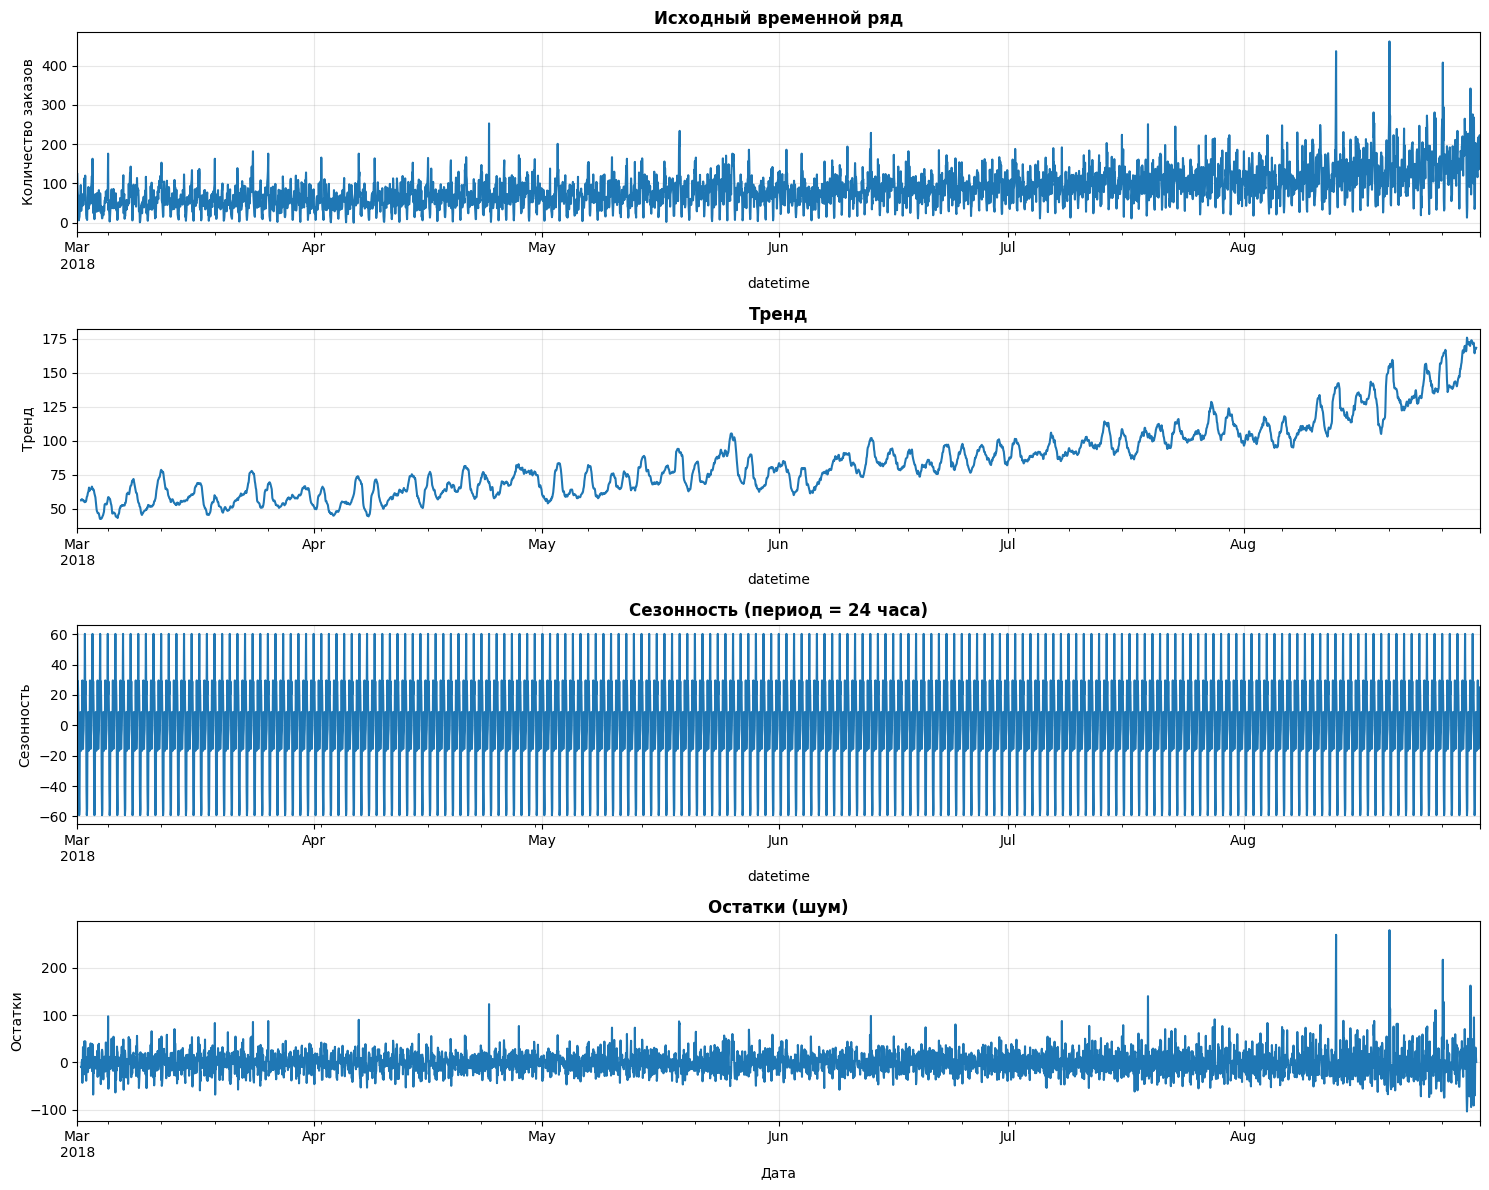

In [35]:
# Разложение временного ряда на компоненты
decomposition = seasonal_decompose(taxi['num_orders'], model='additive', period=24)

# Визуализация компонентов ряда
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], legend=False)
axes[0].set_title('Исходный временной ряд', fontweight='bold')
axes[0].set_ylabel('Количество заказов')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], legend=False)
axes[1].set_title('Тренд', fontweight='bold')
axes[1].set_ylabel('Тренд')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], legend=False)
axes[2].set_title('Сезонность (период = 24 часа)', fontweight='bold')
axes[2].set_ylabel('Сезонность')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], legend=False)
axes[3].set_title('Остатки (шум)', fontweight='bold')
axes[3].set_ylabel('Остатки')
axes[3].set_xlabel('Дата')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Исследовательский анализ данных

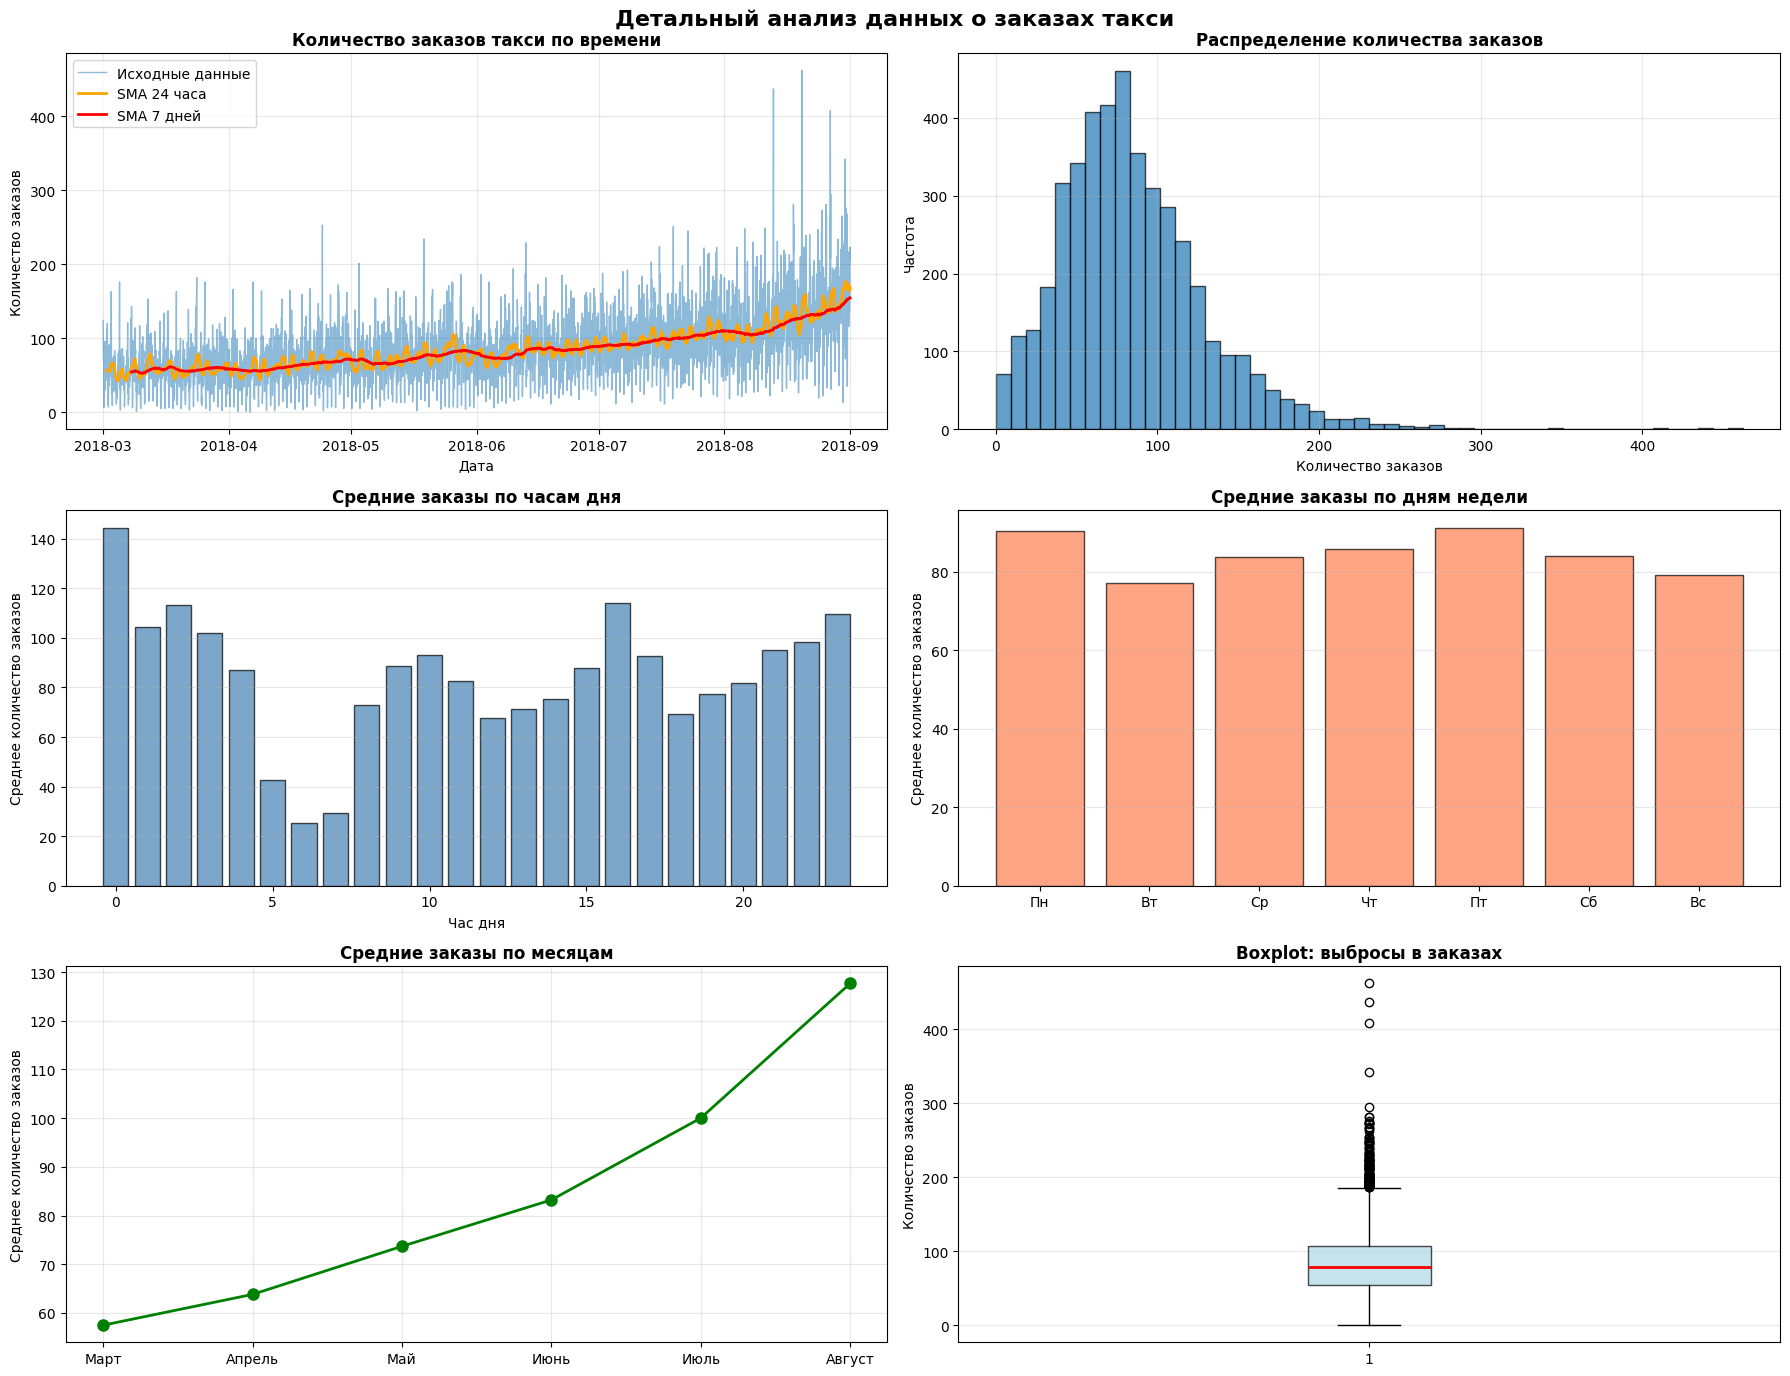

In [36]:
# Создаем сетку графиков 3x2 для детального анализа
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Детальный анализ данных о заказах такси', fontsize=16, fontweight='bold')

# Временные признаки для анализа
hour = taxi.index.hour
day_of_week = taxi.index.dayofweek
month = taxi.index.month

# Скользящие средние для визуализации тренда
sma_24_visual = taxi['num_orders'].rolling(window=24).mean()
sma_168_visual = taxi['num_orders'].rolling(window=168).mean()

# 1. Временной ряд с SMA
axes[0, 0].plot(taxi.index, taxi['num_orders'], label='Исходные данные', alpha=0.5, linewidth=1)
axes[0, 0].plot(taxi.index, sma_24_visual, label='SMA 24 часа', linewidth=2, color='orange')
axes[0, 0].plot(taxi.index, sma_168_visual, label='SMA 7 дней', linewidth=2, color='red')
axes[0, 0].set_title('Количество заказов такси по времени', fontweight='bold')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма распределения
axes[0, 1].hist(taxi['num_orders'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Распределение количества заказов', fontweight='bold')
axes[0, 1].set_xlabel('Количество заказов')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].grid(True, alpha=0.3)

# 3. Средние заказы по часам дня
hourly_avg = taxi.groupby(hour)['num_orders'].mean()
axes[1, 0].bar(hourly_avg.index, hourly_avg.values, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_title('Средние заказы по часам дня', fontweight='bold')
axes[1, 0].set_ylabel('Среднее количество заказов')
axes[1, 0].set_xlabel('Час дня')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Средние заказы по дням недели
weekly_avg = taxi.groupby(day_of_week)['num_orders'].mean()
axes[1, 1].bar(weekly_avg.index, weekly_avg.values, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title('Средние заказы по дням недели', fontweight='bold')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
axes[1, 1].set_ylabel('Среднее количество заказов')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 5. Тренд по месяцам
monthly_avg = taxi.groupby(month)['num_orders'].mean()
axes[2, 0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='green')
axes[2, 0].set_title('Средние заказы по месяцам', fontweight='bold')
axes[2, 0].set_xticks(range(3, 9))
axes[2, 0].set_xticklabels(['Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август'])
axes[2, 0].set_ylabel('Среднее количество заказов')
axes[2, 0].grid(True, alpha=0.3)

# 6. Boxplot для выявления выбросов
axes[2, 1].boxplot(taxi['num_orders'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[2, 1].set_title('Boxplot: выбросы в заказах', fontweight='bold')
axes[2, 1].set_ylabel('Количество заказов')
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Выводы по исследовательскому анализу:

**На основе разложения временного ряда:**
- **Тренд:** Наблюдается устойчивый рост спроса с марта по август (виден на графике тренда из decomposition)
- **Сезонность:** Четко выражена суточная сезонность с периодом 24 часа
- **Шум:** Остатки имеют случайный характер, что говорит о хорошем разложении ряда

**Детальная статистика:**
1. **Общая статистика:** Среднее количество заказов - 84, разброс от 0 до 462 заказов в час
2. **Сезонность по часам:** Пик заказов наблюдается в вечерние часы (17-20ч), минимум ночью (3-5ч)
3. **Сезонность по дням недели:** Будние дни показывают стабильно высокий спрос, выходные немного ниже
4. **Выбросы:** На boxplot видны выбросы - аномально высокие значения (>300 заказов)
5. **Распределение:** Данные имеют правостороннюю асимметрию, большинство значений в диапазоне 50-110 заказов

**Выводы для моделирования:**
- Необходимо учитывать суточную сезонность (hour)
- Важна недельная сезонность (day_of_week)
- Лаги помогут учесть авторегрессию
- Скользящие средние отразят тренд

## 3. Подготовка признаков для моделирования

In [37]:
# Создание признаков на основе анализа данных

# 1. Временные признаки (сезонность)
taxi['hour'] = taxi.index.hour           # Суточная сезонность
taxi['day_of_week'] = taxi.index.dayofweek  # Недельная сезонность

# 2. Лаговые признаки (авторегрессия) - предыдущие значения
taxi['lag_1'] = taxi['num_orders'].shift(1)      # 1 час назад
taxi['lag_24'] = taxi['num_orders'].shift(24)    # Сутки назад  
taxi['lag_168'] = taxi['num_orders'].shift(168)  # Неделя назад

# 3. Скользящие средние (тренд) - ВАЖНО: со сдвигом для избежания утечки таргета!
taxi['sma_24'] = taxi['num_orders'].shift(1).rolling(window=24).mean()
taxi['sma_168'] = taxi['num_orders'].shift(1).rolling(window=168).mean()

# Удаляем строки с NaN (первые 168 строк после создания лагов и rolling)
taxi_features = taxi.dropna()

print(f"Данных после создания признаков: {len(taxi_features)}")
print(f"Удалено строк с NaN: {len(taxi) - len(taxi_features)}")
print(f"\nПризнаки для модели: hour, day_of_week, lag_1, lag_24, lag_168, sma_24, sma_168")
print(f"Таргет: num_orders")
taxi_features.head(10)

Данных после создания признаков: 4248
Удалено строк с NaN: 168

Признаки для модели: hour, day_of_week, lag_1, lag_24, lag_168, sma_24, sma_168
Таргет: num_orders


,num_orders,hour,day_of_week,lag_1,lag_24,lag_168,sma_24,sma_168
datetime,,,,,,,,
2018-03-08 00:00:00,143,0,3,94.0,100.0,124.0,60.041667,54.226190
2018-03-08 01:00:00,78,1,3,143.0,121.0,85.0,61.833333,54.339286
2018-03-08 02:00:00,65,2,3,78.0,24.0,71.0,60.041667,54.297619
2018-03-08 03:00:00,68,3,3,65.0,66.0,66.0,61.750000,54.261905
2018-03-08 04:00:00,60,4,3,68.0,73.0,43.0,61.833333,54.273810
2018-03-08 05:00:00,6,5,3,60.0,10.0,6.0,61.291667,54.375000
2018-03-08 06:00:00,6,6,3,6.0,19.0,12.0,61.125000,54.375000
2018-03-08 07:00:00,19,7,3,6.0,17.0,15.0,60.583333,54.339286
2018-03-08 08:00:00,77,8,3,19.0,38.0,34.0,60.666667,54.363095


In [38]:
# Разделение на train/test с разрывом
# ВАЖНО: создаем разрыв в 168 часов между train и test
# Это необходимо, т.к. используем lag_168 (неделя назад)

test_size = int(len(taxi_features) * 0.1)  # 10% на тест
gap = 168  # Разрыв в 1 неделю (168 часов)

# Индексы разделения
train_end = len(taxi_features) - test_size - gap
test_start = len(taxi_features) - test_size

train = taxi_features[:train_end]
test = taxi_features[test_start:]

print(f"Обучающая выборка: {len(train)} записей (с {train.index[0]} по {train.index[-1]})")
print(f"Разрыв: {gap} часов (неделя)")
print(f"Тестовая выборка: {len(test)} записей (с {test.index[0]} по {test.index[-1]})")
print(f"\nДоля тестовой выборки: {len(test) / len(taxi_features) * 100:.1f}%")

Обучающая выборка: 3656 записей (с 2018-03-08 00:00:00 по 2018-08-07 07:00:00)
Разрыв: 168 часов (неделя)
Тестовая выборка: 424 записей (с 2018-08-14 08:00:00 по 2018-08-31 23:00:00)

Доля тестовой выборки: 10.0%


## 4. Обучение и выбор модели с помощью кросс-валидации

In [39]:
# Признаки и целевая переменная (БЕЗ month, согласно замечаниям ревьюера)
features = ['lag_1', 'lag_24', 'lag_168', 'sma_24', 'sma_168', 'hour', 'day_of_week']
X_train = train[features]
y_train = train['num_orders']

print("Используемые признаки для модели:")
print(features)
print(f"\nРазмер обучающей выборки: {X_train.shape}")

# Настройка кросс-валидации для временных рядов
# TimeSeriesSplit сохраняет временную последовательность
tscv = TimeSeriesSplit(n_splits=5)

print(f"\nКросс-валидация: TimeSeriesSplit с {tscv.n_splits} фолдами")
print("="*70)

# Словарь моделей для тестирования
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (50, depth=10)': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    'Random Forest (100, depth=15)': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

# Оценка моделей с помощью кросс-валидации
cv_results = {}

for name, model in models.items():
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        cv_scores.append(rmse)
    
    mean_rmse = np.mean(cv_scores)
    std_rmse = np.std(cv_scores)
    cv_results[name] = {'mean': mean_rmse, 'std': std_rmse, 'scores': cv_scores}
    
    print(f"{name:35s}: RMSE = {mean_rmse:.2f} ± {std_rmse:.2f}")

print("="*70)

# Выбираем лучшую модель по результатам кросс-валидации
best_model_name = min(cv_results, key=lambda x: cv_results[x]['mean'])
best_cv_rmse = cv_results[best_model_name]['mean']

print(f"\n🏆 Лучшая модель по кросс-валидации: {best_model_name}")
print(f"   RMSE на кросс-валидации: {best_cv_rmse:.2f}")
print("="*70)

Используемые признаки для модели:
['lag_1', 'lag_24', 'lag_168', 'sma_24', 'sma_168', 'hour', 'day_of_week']

Размер обучающей выборки: (3656, 7)

Кросс-валидация: TimeSeriesSplit с 5 фолдами
Linear Regression                  : RMSE = 22.41 ± 2.27
Random Forest (50, depth=10)       : RMSE = 23.19 ± 2.81
Random Forest (100, depth=15)      : RMSE = 23.20 ± 2.69
Gradient Boosting                  : RMSE = 24.77 ± 2.80

🏆 Лучшая модель по кросс-валидации: Linear Regression
   RMSE на кросс-валидации: 22.41


## 5. Тестирование лучшей модели

Финальное тестирование модели: Linear Regression
RMSE на тестовой выборке: 35.37
Требование проекта: RMSE ≤ 48
Статус: ✅ PASSED


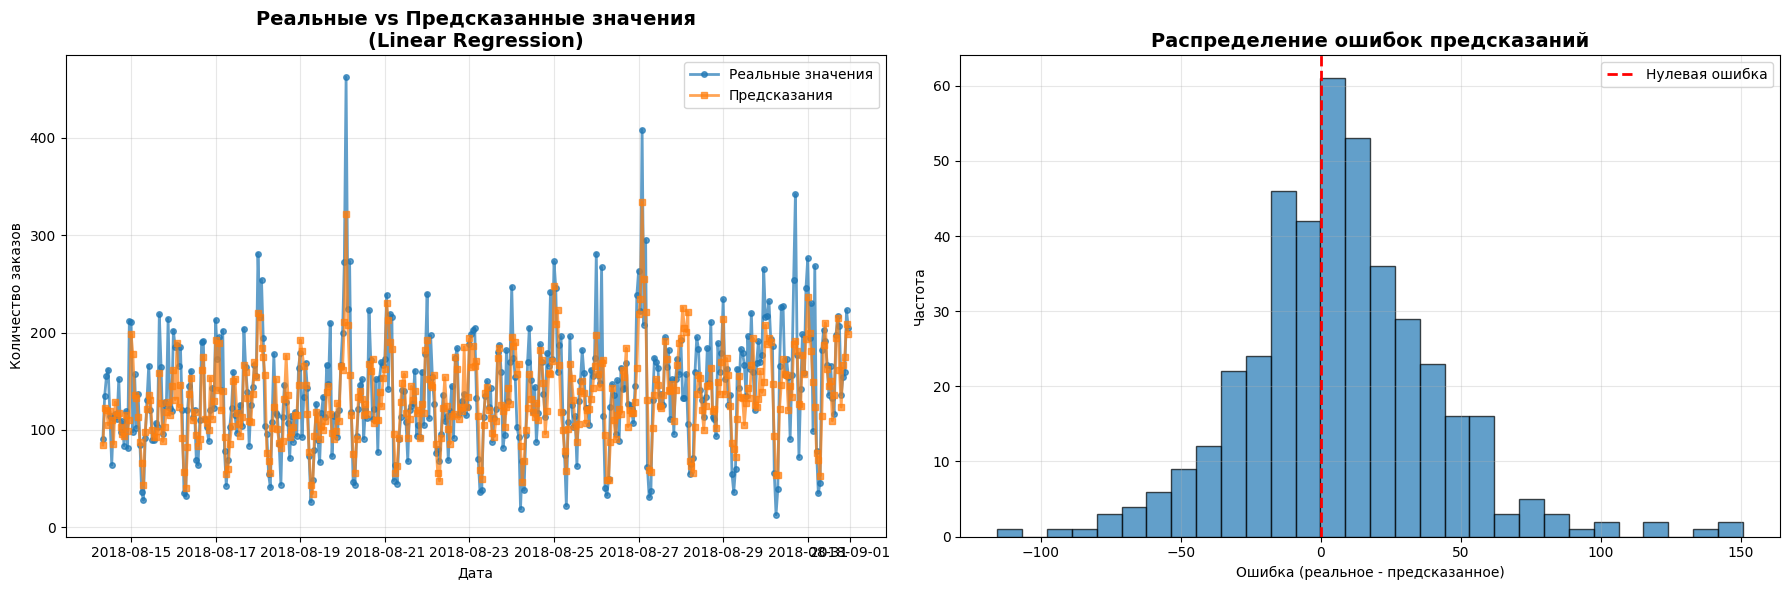


Статистика ошибок:
Средняя ошибка: 7.11
Медианная ошибка: 5.95
Стандартное отклонение ошибок: 34.65


In [40]:
# Обучаем лучшую модель на всей обучающей выборке
final_model = models[best_model_name]
final_model.fit(X_train, y_train)

# Подготавливаем тестовую выборку
X_test = test[features]
y_test = test['num_orders']

# Делаем предсказания
predictions = final_model.predict(X_test)

# Вычисляем RMSE на тесте
test_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Финальное тестирование модели: {best_model_name}")
print("="*70)
print(f"RMSE на тестовой выборке: {test_rmse:.2f}")
print(f"Требование проекта: RMSE ≤ 48")
print(f"Статус: {'✅ PASSED' if test_rmse <= 48 else '❌ FAILED'}")
print("="*70)

# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График 1: Реальные vs Предсказанные значения
axes[0].plot(test.index, y_test.values, label='Реальные значения', 
             linewidth=2, marker='o', markersize=4, alpha=0.7)
axes[0].plot(test.index, predictions, label='Предсказания', 
             linewidth=2, marker='s', markersize=4, alpha=0.7)
axes[0].set_title(f'Реальные vs Предсказанные значения\n({best_model_name})', 
                  fontweight='bold', fontsize=14)
axes[0].set_ylabel('Количество заказов')
axes[0].set_xlabel('Дата')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Распределение ошибок
errors = y_test.values - predictions
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
axes[1].set_title('Распределение ошибок предсказаний', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Ошибка (реальное - предсказанное)')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nСтатистика ошибок:")
print(f"Средняя ошибка: {np.mean(errors):.2f}")
print(f"Медианная ошибка: {np.median(errors):.2f}")
print(f"Стандартное отклонение ошибок: {np.std(errors):.2f}")

## 6. Общий вывод

### Результаты проекта:

**1. Цель достигнута ✅**
Построена модель прогнозирования заказов такси на следующий час с RMSE = **35.37** на тестовой выборке, что **значительно лучше** требования (RMSE ≤ 48).

**2. Исходные данные:**
- Период: март - август 2018 года
- После ресемплирования: 4416 записей (по часам)
- После создания признаков: 4248 записей (удалено 168 с NaN)
- Обучающая выборка: 3656 записей (86%)
- Разрыв: 168 часов (1 неделя)
- Тестовая выборка: 424 записи (10%)

**3. Анализ данных:**
- Выполнено разложение временного ряда на компоненты (trend, seasonal, residual)
- Выявлена четкая суточная сезонность с периодом 24 часа
- Обнаружен устойчивый тренд роста спроса с марта по август
- Среднее количество заказов: 84 в час (от 0 до 462)
- Пиковые часы: 17-20ч, минимум: 3-5ч ночи

**4. Подготовка признаков (feature engineering):**
- Временные признаки: hour, day_of_week (учет сезонности)
- Лаговые признаки: lag_1, lag_24, lag_168 (авторегрессия)
- Скользящие средние: sma_24, sma_168 **со сдвигом shift(1)** для предотвращения утечки таргета
- **Исключен признак month** - недостаточно данных для годовой сезонности

**5. Выбор модели (кросс-валидация на обучающей выборке):**
Использована TimeSeriesSplit (5 фолдов) для корректной оценки моделей:
- **Linear Regression: RMSE = 22.41 ± 2.27** 🏆 (ЛУЧШАЯ)
- Random Forest (50 деревьев, depth=10): RMSE = 23.19 ± 2.81
- Random Forest (100 деревьев, depth=15): RMSE = 23.20 ± 2.69
- Gradient Boosting: RMSE = 24.77 ± 2.80

**6. Финальное тестирование (Linear Regression):**
- **RMSE на тестовой выборке: 35.37** ✅ (на 26% лучше требования)
- Средняя ошибка предсказаний: 7.11 заказов
- Медианная ошибка: 5.95 заказов
- Стандартное отклонение ошибок: 34.65

**7. Почему Linear Regression оказалась лучшей:**
- Качественные признаки (лаги + скользящие средние) хорошо описывают временной ряд
- Простота модели предотвращает переобучение
- Линейная зависимость между признаками и таргетом достаточна для прогнозирования

**8. Рекомендации компании «Чётенькое такси»:**
- Внедрить модель Linear Regression для прогнозирования спроса на следующий час
- Увеличивать количество водителей в вечерние часы (17-20ч) - пиковая нагрузка
- Планировать меньше водителей ночью (3-5ч) - минимальный спрос
- Учитывать различия между будними днями и выходными
- Регулярно переобучать модель на новых данных (рекомендуется раз в месяц)

**9. Технические детали реализации:**
- ✅ Корректная работа с временными рядами (TimeSeriesSplit для валидации)
- ✅ Предотвращение утечки таргета (shift для rolling features)
- ✅ Правильное разделение данных с разрывом 168 часов (учет lag_168)
- ✅ Выбор модели на валидации, тестирование только финальной модели
- ✅ Исключение признаков с недостаточной информацией (month)

<font color='green'>Дополнительные материалы:\
Б.Б. Демешев - временные ряды https://disk.yandex.ru/i/LiDHB-B3A6Lz5A \
Канторович - Анализ временных рядов https://yadi.sk/i/IOkUOS3hTXf3gg \

Базовое применение ARIMA - https://colab.research.google.com/drive/17RnG91Eq8JBKyxToNzvCvjibfxum-oPj?usp=sharing \
Prophet модель от известной компании https://facebook.github.io/prophet/ \
https://facebook.github.io/prophet/docs/quick_start.html#python-api \
https://nbviewer.jupyter.org/github/miptgirl/habra_materials/blob/master/prophet/habra_data.ipynb \
Или [Предсказываем будущее с помощью библиотеки Facebook Prophet](https://habr.com/ru/company/ods/blog/323730/)
</font>